In [ ]:
# 1. Install MediaPipe, OpenCV, and Protobuf
!pip install -q "protobuf>=5.28.0" mediapipe opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.8 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
from google.colab import drive

# 2. Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 3. Paths based on your Drive structure
ZIP_PATH = '/content/drive/MyDrive/SignLanguageProject/wlasl-processed.zip'
LOCAL_VIDEO_DIR = '/content/videos'

# 4. Unzip dataset to high-speed local storage
if not os.path.exists(LOCAL_VIDEO_DIR):
    os.makedirs(LOCAL_VIDEO_DIR)
    print("Unzipping dataset to local storage... This will take a few minutes.")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_VIDEO_DIR)
    print("Unzipping complete!")
else:
    print("Dataset already unzipped locally.")

# Re-download missing MediaPipe task models
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
print("Task models downloaded successfully!")

Unzipping dataset to local storage... This will take a few minutes.
Unzipping complete!
Task models downloaded successfully!


# PREPROCESSING

In [ ]:
import json
import os
import glob
import cv2
import numpy as np
import pandas as pd
from collections import Counter

# --- PATH CONFIGURATION ---
# Check where the JSON metadata file is located after unzipping
json_matches = glob.glob('/content/videos/**/WLASL_v0.3.json', recursive=True) or \
               glob.glob('/content/videos/**/*.json', recursive=True) or \
               glob.glob('/content/drive/MyDrive/SignLanguageProject/*.json', recursive=True)

if not json_matches:
    print("⚠️ Metadata JSON not found in default paths! Please verify where the .json file was extracted.")
    JSON_PATH = None
else:
    JSON_PATH = json_matches[0]
    print(f"📁 Found metadata file at: {JSON_PATH}")

VIDEO_DIR = '/content/videos'

# --- 1. METADATA ANALYSIS (CLASSES & INSTANCES) ---
if JSON_PATH and os.path.exists(JSON_PATH):
    with open(JSON_PATH, 'r') as f:
        wlasl_data = json.load(f)

    total_words = len(wlasl_data)
    total_samples = 0
    samples_per_word = []

    for entry in wlasl_data:
        gloss = entry['gloss']
        instances = entry['instances']
        count = len(instances)
        total_samples += count
        samples_per_word.append(count)

    print("="*50)
    print("📊 DATASET OVERVIEW (METADATA)")
    print("="*50)
    print(f"Total Unique Classes (Words/Glosses): {total_words}")
    print(f"Total Video Instances (in JSON):    {total_samples}")
    print(f"Average Samples per Word:           {np.mean(samples_per_word):.2f}")
    print(f"Max Samples for a Single Word:      {np.max(samples_per_word)} (Word: '{wlasl_data[np.argmax(samples_per_word)]['gloss']}')")
    print(f"Min Samples for a Single Word:      {np.min(samples_per_word)}")
    print("="*50)

# --- 2. PHYSICAL VIDEO FILE INSPECTION (FPS, DURATION, RESOLUTION) ---
print("\n🔍 PROFILING PHYSICAL VIDEO FILES...")

video_files = []
for root, dirs, files in os.walk(VIDEO_DIR):
    for file in files:
        if file.endswith('.mp4'):
            video_files.append(os.path.join(root, file))

print(f"Total .mp4 Video Files Found on Disk: {len(video_files)}")

# Sample up to 300 videos to analyze physical properties efficiently
sample_size = min(300, len(video_files))
sampled_videos = np.random.choice(video_files, sample_size, replace=False)

fps_list = []
frame_counts = []
durations = []
resolutions = []
aspect_ratios = []

for vid in sampled_videos:
    cap = cv2.VideoCapture(vid)
    if not cap.isOpened():
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    f_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps > 0 and f_count > 0:
        duration = f_count / fps
        fps_list.append(fps)
        frame_counts.append(f_count)
        durations.append(duration)
        resolutions.append((width, height))
        aspect_ratios.append(f"{width}x{height}")

    cap.release()

print("\n" + "="*50)
print("🎥 PHYSICAL VIDEO METRICS (Sampled from 300 files)")
print("="*50)
print(f"FPS Range:             {np.min(fps_list):.1f} to {np.max(fps_list):.1f} FPS (Most Common: {Counter(fps_list).most_common(1)[0][0]:.1f} FPS)")
print(f"Frame Count Range:     {np.min(frame_counts)} to {np.max(frame_counts)} frames")
print(f"Average Frame Count:   {np.mean(frame_counts):.1f} frames")
print(f"Duration Range:        {np.min(durations):.2f}s to {np.max(durations):.2f}s")
print(f"Average Duration:      {np.mean(durations):.2f} seconds")
print(f"Top 3 Resolutions:     {Counter(aspect_ratios).most_common(3)}")
print("="*50)

📁 Found metadata file at: /content/videos/WLASL_v0.3.json
📊 DATASET OVERVIEW (METADATA)
Total Unique Classes (Words/Glosses): 2000
Total Video Instances (in JSON):    21083
Average Samples per Word:           10.54
Max Samples for a Single Word:      40 (Word: 'book')
Min Samples for a Single Word:      6

🔍 PROFILING PHYSICAL VIDEO FILES...
Total .mp4 Video Files Found on Disk: 11980

🎥 PHYSICAL VIDEO METRICS (Sampled from 300 files)
FPS Range:             24.0 to 50.0 FPS (Most Common: 30.0 FPS)
Frame Count Range:     22 to 158 frames
Average Frame Count:   70.4 frames
Duration Range:        0.83s to 6.58s
Average Duration:      2.46 seconds
Top 3 Resolutions:     [('288x192', 64), ('720x400', 56), ('640x480', 44)]


# EXTRACTING TOP 100 WORDS & EXTRACTING LANDMARKS

In [ ]:
import json
import os
import cv2
import numpy as np
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TOP_N_CLASSES = 100
JSON_PATH = '/content/videos/WLASL_v0.3.json'
VIDEO_DIR = '/content/videos'
OUTPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
MAPPING_SAVE_PATH = '/content/drive/MyDrive/SignLanguageProject/class_mapping_100.json'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. ENSURE TASK MODEL FILES ARE PRESENT ---
POSE_MODEL_PATH = 'pose_landmarker.task'
HAND_MODEL_PATH = 'hand_landmarker.task'

POSE_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
HAND_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

if not os.path.exists(POSE_MODEL_PATH):
    print("Downloading pose landmarker model...")
    urllib.request.urlretrieve(POSE_URL, POSE_MODEL_PATH)

if not os.path.exists(HAND_MODEL_PATH):
    print("Downloading hand landmarker model...")
    urllib.request.urlretrieve(HAND_URL, HAND_MODEL_PATH)

print("Task model files verified!")

# --- 3. SELECT TOP 100 CLASSES & SAVE MAPPING ---
with open(JSON_PATH, 'r') as f:
    wlasl_data = json.load(f)

# Sort glosses by number of instances in descending order
sorted_glosses = sorted(wlasl_data, key=lambda x: len(x['instances']), reverse=True)[:TOP_N_CLASSES]

target_video_ids = set()
class_mapping = {}

for idx, entry in enumerate(sorted_glosses):
    gloss = entry['gloss']
    class_mapping[gloss] = idx
    for inst in entry['instances']:
        target_video_ids.add(str(inst['video_id']))

print(f"Targeting Top {TOP_N_CLASSES} Classes.")
print(f"Total video instances in metadata for Top {TOP_N_CLASSES}: {len(target_video_ids)}")

# Save class-to-index mapping for training/evaluation
with open(MAPPING_SAVE_PATH, 'w') as f:
    json.dump(class_mapping, f, indent=4)
print(f"Saved class index mapping to: {MAPPING_SAVE_PATH}")

# --- 4. FILTER LOCAL FILES FOR MATCHING VIDEOS ---
selected_video_files = []
for root, dirs, files in os.walk(VIDEO_DIR):
    for file in files:
        if file.endswith('.mp4'):
            vid_id = os.path.splitext(file)[0]
            if vid_id in target_video_ids:
                selected_video_files.append(os.path.join(root, file))

print(f"Found {len(selected_video_files)} physical .mp4 files on disk matching WLASL-100.")

# --- 5. INITIALIZE MEDIAPIPE DETECTORS ---
base_options_pose = python.BaseOptions(
    model_asset_path=POSE_MODEL_PATH,
    delegate=python.BaseOptions.Delegate.CPU
)
options_pose = vision.PoseLandmarkerOptions(base_options=base_options_pose)
pose_detector = vision.PoseLandmarker.create_from_options(options_pose)

base_options_hand = python.BaseOptions(
    model_asset_path=HAND_MODEL_PATH,
    delegate=python.BaseOptions.Delegate.CPU
)
options_hand = vision.HandLandmarkerOptions(base_options=base_options_hand, num_hands=2)
hand_detector = vision.HandLandmarker.create_from_options(options_hand)


def extract_keypoints(pose_result, hand_result):
    """
    Constructs a fixed 258-length feature vector per frame:
    - Pose: 33 points * 4 (x, y, z, visibility) = 132
    - Left Hand: 21 points * 3 (x, y, z) = 63
    - Right Hand: 21 points * 3 (x, y, z) = 63
    """
    if pose_result.pose_landmarks and len(pose_result.pose_landmarks) > 0:
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in pose_result.pose_landmarks[0]]).flatten()
    else:
        pose = np.zeros(33 * 4)

    lh = np.zeros(21 * 3)
    rh = np.zeros(21 * 3)

    if hand_result.hand_landmarks and hand_result.handedness:
        for idx, hand_info in enumerate(hand_result.handedness):
            label = hand_info[0].category_name
            landmarks = np.array([[res.x, res.y, res.z] for res in hand_result.hand_landmarks[idx]]).flatten()
            if label == 'Left':
                lh = landmarks
            elif label == 'Right':
                rh = landmarks

    return np.concatenate([pose, lh, rh])


def process_video(video_path, frame_stride=2):
    """Reads video and extracts landmarks every Nth frame."""
    cap = cv2.VideoCapture(video_path)
    frames_data = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_stride == 0:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

            pose_res = pose_detector.detect(mp_image)
            hand_res = hand_detector.detect(mp_image)

            keypoints = extract_keypoints(pose_res, hand_res)
            frames_data.append(keypoints)

        frame_idx += 1

    cap.release()
    return np.array(frames_data)


# --- 6. RUN BATCH EXTRACTION ---
for video_path in tqdm(selected_video_files, desc="Extracting WLASL-100 Landmarks"):
    video_id = os.path.splitext(os.path.basename(video_path))[0]
    save_path = os.path.join(OUTPUT_DIR, f"{video_id}.npy")

    # Fault tolerance: Skip if already extracted
    if os.path.exists(save_path):
        continue

    try:
        sequence_data = process_video(video_path, frame_stride=2)
        np.save(save_path, sequence_data)
    except Exception as e:
        print(f"Error processing {video_path}: {e}")

print("\nExtraction complete! All WLASL-100 landmarks and class mappings are safely stored on Google Drive.")

Task model files verified!
Targeting Top 100 Classes.
Total video instances in metadata for Top 100: 2038
Saved class index mapping to: /content/drive/MyDrive/SignLanguageProject/class_mapping_100.json
Found 1013 physical .mp4 files on disk matching WLASL-100.


Extracting WLASL-100 Landmarks: 100%|██████████| 1013/1013 [1:30:27<00:00,  5.36s/it]


Extraction complete! All WLASL-100 landmarks and class mappings are safely stored on Google Drive.


# SAMPLE LANDMARK

In [ ]:
import os
import cv2
import glob
import numpy as np
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# --- 1. PATHS & SETUP ---
VIDEO_DIR = '/content/videos'
SAVE_DIR = '/content/drive/MyDrive/SignLanguageProject'
OUTPUT_VIDEO_PATH = os.path.join(SAVE_DIR, 'sample_landmark_overlay.mp4')

os.makedirs(SAVE_DIR, exist_ok=True)

# Ensure model files are available
POSE_MODEL_PATH = 'pose_landmarker.task'
HAND_MODEL_PATH = 'hand_landmarker.task'

POSE_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
HAND_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

if not os.path.exists(POSE_MODEL_PATH):
    print("Downloading pose model...")
    urllib.request.urlretrieve(POSE_URL, POSE_MODEL_PATH)

if not os.path.exists(HAND_MODEL_PATH):
    print("Downloading hand model...")
    urllib.request.urlretrieve(HAND_URL, HAND_MODEL_PATH)

# --- 2. PICK A SAMPLE VIDEO ---
mp4_files = glob.glob(os.path.join(VIDEO_DIR, '**/*.mp4'), recursive=True)
if not mp4_files:
    raise FileNotFoundError("No .mp4 files found in /content/videos!")

sample_video_path = mp4_files[0]
print(f"Rendering landmarks for sample video: {sample_video_path}")

# --- 3. INITIALIZE DETECTORS & DRAWING CONNECTIONS ---
base_options_pose = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)
options_pose = vision.PoseLandmarkerOptions(base_options=base_options_pose)
pose_detector = vision.PoseLandmarker.create_from_options(options_pose)

base_options_hand = python.BaseOptions(model_asset_path=HAND_MODEL_PATH)
options_hand = vision.HandLandmarkerOptions(base_options=base_options_hand, num_hands=2)
hand_detector = vision.HandLandmarker.create_from_options(options_hand)

# Connections for manual drawing
POSE_CONNECTIONS = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16), # Arms
    (11, 23), (12, 24), (23, 24)                     # Torso
]

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index
    (5, 9), (9, 10), (10, 11), (11, 12),   # Middle
    (9, 13), (13, 14), (14, 15), (15, 16), # Ring
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20) # Pinky
]

def draw_landmarks_on_frame(frame, pose_res, hand_res):
    h, w, _ = frame.shape

    # Draw Pose
    if pose_res.pose_landmarks and len(pose_res.pose_landmarks) > 0:
        landmarks = pose_res.pose_landmarks[0]
        # Draw upper body points
        for idx in range(25):
            lm = landmarks[idx]
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(frame, (cx, cy), 4, (255, 0, 0), -1) # Blue joints
        # Draw skeleton lines
        for p1, p2 in POSE_CONNECTIONS:
            lm1, lm2 = landmarks[p1], landmarks[p2]
            pt1 = (int(lm1.x * w), int(lm1.y * h))
            pt2 = (int(lm2.x * w), int(lm2.y * h))
            cv2.line(frame, pt1, pt2, (255, 255, 0), 2)

    # Draw Hands
    if hand_res.hand_landmarks:
        for hand_landmarks in hand_res.hand_landmarks:
            # Draw joints
            for lm in hand_landmarks:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(frame, (cx, cy), 3, (0, 255, 0), -1) # Green hand joints
            # Draw finger connections
            for p1, p2 in HAND_CONNECTIONS:
                lm1, lm2 = hand_landmarks[p1], hand_landmarks[p2]
                pt1 = (int(lm1.x * w), int(lm1.y * h))
                pt2 = (int(lm2.x * w), int(lm2.y * h))
                cv2.line(frame, pt1, pt2, (0, 0, 255), 1) # Red connections

    return frame

# --- 4. PROCESS VIDEO & SAVE TO DRIVE ---
cap = cv2.VideoCapture(sample_video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

print("Rendering landmark overlay video...")
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    pose_res = pose_detector.detect(mp_image)
    hand_res = hand_detector.detect(mp_image)

    annotated_frame = draw_landmarks_on_frame(frame, pose_res, hand_res)
    out.write(annotated_frame)
    frame_count += 1

cap.release()
out.release()

print(f"Finished rendering {frame_count} frames!")
print(f"Sample video saved to Drive at: {OUTPUT_VIDEO_PATH}")

Rendering landmarks for sample video: /content/videos/videos/10647.mp4
Rendering landmark overlay video...
Finished rendering 38 frames!
Sample video saved to Drive at: /content/drive/MyDrive/SignLanguageProject/sample_landmark_overlay.mp4


# LANDMARK EVALUATION

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

# --- 1. DIRECTORY SETUP ---
NPY_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
npy_files = glob.glob(os.path.join(NPY_DIR, '*.npy'))

print(f"Scanning {len(npy_files)} extracted landmark files...")

stats = []

# --- 2. ANALYZE EACH FILE ---
for file_path in npy_files:
    file_id = os.path.basename(file_path).replace('.npy', '')

    try:
        data = np.load(file_path)
    except Exception as e:
        stats.append({'id': file_id, 'frames': 0, 'hand_presence_pct': 0, 'corrupted': True})
        continue

    num_frames = data.shape[0]

    # Catch empty arrays
    if num_frames == 0:
        stats.append({'id': file_id, 'frames': 0, 'hand_presence_pct': 0, 'corrupted': True})
        continue

    # Check feature dimension (should be exactly 258)
    feat_dim = data.shape[1]

    # Hand landmarks span indices 132 to 257 (Left: 132-194, Right: 195-257)
    hand_data = data[:, 132:]

    # A frame successfully tracked hands if the sum of absolute values is > 0
    frames_with_hands = np.sum(np.abs(hand_data).sum(axis=1) > 0)
    hand_presence_pct = (frames_with_hands / num_frames) * 100

    stats.append({
        'id': file_id,
        'frames': num_frames,
        'feat_dim': feat_dim,
        'hand_presence_pct': hand_presence_pct,
        'corrupted': False
    })

# --- 3. GENERATE REPORT ---
df_stats = pd.DataFrame(stats)
valid_df = df_stats[~df_stats['corrupted']]

print("\n" + "="*50)
print("📊 DATASET HEALTH & ACCURACY REPORT")
print("="*50)
print(f"Total Valid Files:           {len(valid_df)} / {len(npy_files)}")
print(f"Corrupted / Empty Files:     {df_stats['corrupted'].sum()}")

if not valid_df.empty:
    print(f"Feature Dimension Check:     {valid_df['feat_dim'].iloc[0]} (Expected: 258)")
    print(f"Frame Count - Min:           {valid_df['frames'].min()}")
    print(f"Frame Count - Max:           {valid_df['frames'].max()}")
    print(f"Frame Count - Average:       {valid_df['frames'].mean():.1f}")
    print(f"Average Hand Detection Rate: {valid_df['hand_presence_pct'].mean():.1f}%")
print("="*50)

# --- 4. FLAG LOW-QUALITY DATA ---
# A detection rate below 30% usually means the sign is entirely missed or out of frame
low_quality = valid_df[valid_df['hand_presence_pct'] < 30]

print(f"\n⚠️ Files with poor hand tracking (<30% of frames): {len(low_quality)}")

if len(low_quality) > 0:
    print("\nSample of low-quality files to potentially drop before training:")
    print(low_quality[['id', 'frames', 'hand_presence_pct']].head(10).to_string(index=False))

Scanning 1013 extracted landmark files...

📊 DATASET HEALTH & ACCURACY REPORT
Total Valid Files:           1013 / 1013
Corrupted / Empty Files:     0
Feature Dimension Check:     258 (Expected: 258)
Frame Count - Min:           10
Frame Count - Max:           98
Frame Count - Average:       32.8
Average Hand Detection Rate: 65.7%

⚠️ Files with poor hand tracking (<30% of frames): 22

Sample of low-quality files to potentially drop before training:
   id  frames  hand_presence_pct
62158      47          27.659574
63664      61          26.229508
17097      44          29.545455
06486      56          28.571429
38544      42          28.571429
65403      37          27.027027
26712      46           2.173913
05749      45          26.666667
13695      36          19.444444
18324      34          29.411765


# DATA ANALYSIS (HAND GESTURE LANDMARK COMPLETENESS)

In [ ]:
import os
import glob
import json
import pandas as pd
from collections import Counter

# --- 1. PATHS ---
NPY_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
JSON_PATH = '/content/videos/WLASL_v0.3.json'

# --- 2. BUILD VIDEO ID TO GLOSS MAPPING ---
with open(JSON_PATH, 'r') as f:
    wlasl_data = json.load(f)

video_to_gloss = {}
for entry in wlasl_data:
    gloss = entry['gloss']
    for inst in entry['instances']:
        video_to_gloss[str(inst['video_id'])] = gloss

# --- 3. TALLY REMAINING VALID FILES ---
npy_files = glob.glob(os.path.join(NPY_DIR, '*.npy'))
print(f"Total clean .npy files found on disk: {len(npy_files)}")

gloss_counts = Counter()
missing_mapping = 0

for file_path in npy_files:
    video_id = os.path.basename(file_path).replace('.npy', '')
    if video_id in video_to_gloss:
        gloss = video_to_gloss[video_id]
        gloss_counts[gloss] += 1
    else:
        missing_mapping += 1

# --- 4. COMPUTE & DISPLAY STATISTICS ---
df_counts = pd.DataFrame(gloss_counts.items(), columns=['Gloss', 'Sample_Count'])

if df_counts.empty:
    print("No matching data found. Check your directories.")
else:
    total_words = len(df_counts)
    total_samples = df_counts['Sample_Count'].sum()
    mean_samples = df_counts['Sample_Count'].mean()
    min_samples = df_counts['Sample_Count'].min()
    max_samples = df_counts['Sample_Count'].max()

    print("\n" + "="*50)
    print("📊 FINAL DATASET BIBLIOMETRIC ANALYSIS")
    print("="*50)
    print(f"Total Unique Words (Classes): {total_words} (Target was 100)")
    print(f"Total Valid Video Samples:    {total_samples}")
    print(f"Average Samples per Word:     {mean_samples:.2f}")
    print(f"Minimum Samples for a Word:   {min_samples}")
    print(f"Maximum Samples for a Word:   {max_samples}")

    if missing_mapping > 0:
        print(f"⚠️ Files missing from JSON:    {missing_mapping}")
    print("="*50 + "\n")

    print("📈 Top 5 Most Represented Words:")
    print(df_counts.sort_values(by='Sample_Count', ascending=False).head(5).to_string(index=False))

    print("\n📉 Bottom 5 Least Represented Words:")
    print(df_counts.sort_values(by='Sample_Count', ascending=True).head(5).to_string(index=False))

    # --- 5. IMPORTANT ML INSIGHTS ---
    print("\n" + "="*50)
    print("🧠 MACHINE LEARNING INSIGHTS")
    print("="*50)

    # Check 1: Did we lose any classes?
    if total_words < 100:
        print(f"-> WARNING: You lost {100 - total_words} entire word classes during extraction/purging. Your model output dimension must be {total_words}, not 100.")
    else:
        print("-> SUCCESS: All 100 classes are still represented in the data.")

    # Check 2: Class Imbalance
    imbalance_ratio = max_samples / min_samples
    print(f"-> Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}x")
    if imbalance_ratio > 2.0:
        print("-> ACTION REQUIRED: High class imbalance detected. You should use a weighted loss function (e.g., passing class weights to PyTorch's CrossEntropyLoss) to prevent the model from ignoring the bottom words.")


Total clean .npy files found on disk: 1013

📊 FINAL DATASET BIBLIOMETRIC ANALYSIS
Total Unique Words (Classes): 100 (Target was 100)
Total Valid Video Samples:    1013
Average Samples per Word:     10.13
Minimum Samples for a Word:   5
Maximum Samples for a Word:   16

📈 Top 5 Most Represented Words:
 Gloss  Sample_Count
before            16
  thin            16
  cool            16
    go            15
 drink            15

📉 Bottom 5 Least Represented Words:
   Gloss  Sample_Count
 clothes             5
   table             5
    need             6
birthday             6
    book             6

🧠 MACHINE LEARNING INSIGHTS
-> SUCCESS: All 100 classes are still represented in the data.
-> Imbalance Ratio (Max/Min): 3.20x
-> ACTION REQUIRED: High class imbalance detected. You should use a weighted loss function (e.g., passing class weights to PyTorch's CrossEntropyLoss) to prevent the model from ignoring the bottom words.


# DATA PRUNING

In [ ]:
import os
import glob
import shutil
import numpy as np
from tqdm import tqdm

# --- 1. DIRECTORY CONFIGURATION ---
NPY_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
PRUNED_DIR = '/content/drive/MyDrive/SignLanguageProject/pruned_landmarks'

os.makedirs(PRUNED_DIR, exist_ok=True)

# --- 2. PRUNING THRESHOLDS ---
MIN_HAND_PRESENCE_PCT = 30.0  # At least 30% of frames must have hands
MIN_FRAME_COUNT = 15          # Video must be at least 15 frames long

# --- 3. EXECUTE PRUNING ---
npy_files = glob.glob(os.path.join(NPY_DIR, '*.npy'))
print(f"Scanning {len(npy_files)} files for pruning...")

pruned_count_hands = 0
pruned_count_length = 0
pruned_count_empty = 0

for file_path in tqdm(npy_files, desc="Evaluating Landmarks"):
    filename = os.path.basename(file_path)
    destination = os.path.join(PRUNED_DIR, filename)

    try:
        data = np.load(file_path)
    except Exception:
        shutil.move(file_path, destination)
        pruned_count_empty += 1
        continue

    num_frames = data.shape[0]

    # Condition 1: Empty or severely truncated sequences
    if num_frames < MIN_FRAME_COUNT:
        shutil.move(file_path, destination)
        pruned_count_length += 1
        continue

    # Condition 2: Poor hand tracking
    # Hand data spans indices 132 to 257
    hand_data = data[:, 132:]
    frames_with_hands = np.sum(np.abs(hand_data).sum(axis=1) > 0)
    hand_presence_pct = (frames_with_hands / num_frames) * 100

    if hand_presence_pct < MIN_HAND_PRESENCE_PCT:
        shutil.move(file_path, destination)
        pruned_count_hands += 1

# --- 4. SUMMARY REPORT ---
print("\n" + "="*50)
print("✂️ DATASET PRUNING SUMMARY")
print("="*50)
print(f"Total Files Scanned:           {len(npy_files)}")
print(f"Files Kept (Healthy Data):     {len(npy_files) - (pruned_count_empty + pruned_count_length + pruned_count_hands)}")
print(f"Files Pruned (Total):          {pruned_count_empty + pruned_count_length + pruned_count_hands}")
print("-" * 50)
print(f"  -> Pruned due to <15 frames: {pruned_count_length}")
print(f"  -> Pruned due to <30% hands: {pruned_count_hands}")
print(f"  -> Pruned due to read error: {pruned_count_empty}")
print("="*50)
print(f"Bad data moved to: {PRUNED_DIR}")

Scanning 1013 files for pruning...


Evaluating Landmarks: 100%|██████████| 1013/1013 [00:10<00:00, 95.32it/s]


✂️ DATASET PRUNING SUMMARY
Total Files Scanned:           1013
Files Kept (Healthy Data):     954
Files Pruned (Total):          59
--------------------------------------------------
  -> Pruned due to <15 frames: 38
  -> Pruned due to <30% hands: 21
  -> Pruned due to read error: 0
Bad data moved to: /content/drive/MyDrive/SignLanguageProject/pruned_landmarks


# COMAPRING PRUNED DATA VS HEALTHY DATA


In [ ]:
import os
import glob
import json
import pandas as pd
from collections import Counter

# --- 1. PATHS ---
HEALTHY_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
PRUNED_DIR = '/content/drive/MyDrive/SignLanguageProject/pruned_landmarks'
JSON_PATH = '/content/videos/WLASL_v0.3.json'

# --- 2. BUILD VIDEO ID TO GLOSS MAPPING ---
with open(JSON_PATH, 'r') as f:
    wlasl_data = json.load(f)

video_to_gloss = {}
for entry in wlasl_data:
    gloss = entry['gloss']
    for inst in entry['instances']:
        video_to_gloss[str(inst['video_id'])] = gloss

# --- 3. ANALYSIS FUNCTION ---
def analyze_dataset(directory, dataset_name):
    npy_files = glob.glob(os.path.join(directory, '*.npy'))
    print(f"\n" + "="*60)
    print(f"📊 ANALYSIS FOR: {dataset_name.upper()} ({directory})")
    print("="*60)
    print(f"Total .npy files found on disk: {len(npy_files)}")

    if len(npy_files) == 0:
        print("No files found in this directory.")
        return None

    gloss_counts = Counter()
    missing_mapping = 0

    for file_path in npy_files:
        video_id = os.path.basename(file_path).replace('.npy', '')
        if video_id in video_to_gloss:
            gloss = video_to_gloss[video_id]
            gloss_counts[gloss] += 1
        else:
            missing_mapping += 1

    df_counts = pd.DataFrame(gloss_counts.items(), columns=['Gloss', 'Sample_Count'])

    if df_counts.empty:
        print("No matching data found. Check your JSON mapping.")
        return None

    total_words = len(df_counts)
    total_samples = df_counts['Sample_Count'].sum()
    mean_samples = df_counts['Sample_Count'].mean()
    min_samples = df_counts['Sample_Count'].min()
    max_samples = df_counts['Sample_Count'].max()

    print(f"Total Unique Words (Classes): {total_words}")
    print(f"Total Valid Video Samples:    {total_samples}")
    print(f"Average Samples per Word:     {mean_samples:.2f}")
    print(f"Minimum Samples for a Word:   {min_samples}")
    print(f"Maximum Samples for a Word:   {max_samples}")

    if missing_mapping > 0:
        print(f"⚠️ Files missing from JSON:    {missing_mapping}")

    print("\n📈 Top 5 Most Represented Words:")
    print(df_counts.sort_values(by='Sample_Count', ascending=False).head(5).to_string(index=False))

    print("\n📉 Bottom 5 Least Represented Words:")
    print(df_counts.sort_values(by='Sample_Count', ascending=True).head(5).to_string(index=False))

    return df_counts

# --- 4. RUN ANALYSIS ---
healthy_df = analyze_dataset(HEALTHY_DIR, "Healthy / Kept Data")
pruned_df = analyze_dataset(PRUNED_DIR, "Pruned / Bad Data")

# --- 5. COMPARISON INSIGHTS ---
print("\n" + "="*60)
print("🧠 COMPARATIVE INSIGHTS")
print("="*60)

if healthy_df is not None and pruned_df is not None:
    healthy_words = set(healthy_df['Gloss'])
    pruned_words = set(pruned_df['Gloss'])

    # Identify words that exist in the pruned directory but no longer in the healthy directory
    lost_words = pruned_words - healthy_words

    print(f"Total words completely lost to pruning: {len(lost_words)}")
    if len(lost_words) > 0:
        print(f"Words completely removed from dataset: {', '.join(lost_words)}")
        print(f"-> WARNING: Your model output dimension must be {len(healthy_words)}, not 100.")
    else:
        print("-> SUCCESS: All classes survived the pruning process.")

    print("\nTop 5 Words Most Affected by Pruning (Most samples lost):")
    print(pruned_df.sort_values(by='Sample_Count', ascending=False).head(5).to_string(index=False))


📊 ANALYSIS FOR: HEALTHY / KEPT DATA (/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100)
Total .npy files found on disk: 954
Total Unique Words (Classes): 100
Total Valid Video Samples:    954
Average Samples per Word:     9.54
Minimum Samples for a Word:   5
Maximum Samples for a Word:   16

📈 Top 5 Most Represented Words:
   Gloss  Sample_Count
    thin            16
      go            15
   drink            15
     who            14
computer            14

📉 Bottom 5 Least Represented Words:
  Gloss  Sample_Count
  table             5
clothes             5
    but             6
   need             6
    eat             6

📊 ANALYSIS FOR: PRUNED / BAD DATA (/content/drive/MyDrive/SignLanguageProject/pruned_landmarks)
Total .npy files found on disk: 59
Total Unique Words (Classes): 40
Total Valid Video Samples:    59
Average Samples per Word:     1.48
Minimum Samples for a Word:   1
Maximum Samples for a Word:   4

📈 Top 5 Most Represented Words:
 Gloss  Sample_Count


In [ ]:
import os
import glob
import numpy as np
import pandas as pd

def analyze_landmark_quality(npy_dir, dataset_name):
    npy_files = glob.glob(os.path.join(npy_dir, '*.npy'))

    print(f"\n" + "="*60)
    print(f"📊 DATASET HEALTH & ACCURACY REPORT: {dataset_name}")
    print("="*60)
    print(f"Scanning {len(npy_files)} extracted landmark files in {npy_dir}...")

    if len(npy_files) == 0:
        print("No files found in this directory.")
        return

    stats = []

    # --- 1. ANALYZE EACH FILE ---
    for file_path in npy_files:
        file_id = os.path.basename(file_path).replace('.npy', '')

        try:
            data = np.load(file_path)
        except Exception as e:
            stats.append({'id': file_id, 'frames': 0, 'hand_presence_pct': 0, 'corrupted': True})
            continue

        num_frames = data.shape[0]

        # Catch empty arrays
        if num_frames == 0:
            stats.append({'id': file_id, 'frames': 0, 'hand_presence_pct': 0, 'corrupted': True})
            continue

        # Check feature dimension (should be exactly 258)
        feat_dim = data.shape[1]

        # Hand landmarks span indices 132 to 257 (Left: 132-194, Right: 195-257)
        hand_data = data[:, 132:]

        # A frame successfully tracked hands if the sum of absolute values is > 0
        frames_with_hands = np.sum(np.abs(hand_data).sum(axis=1) > 0)
        hand_presence_pct = (frames_with_hands / num_frames) * 100

        stats.append({
            'id': file_id,
            'frames': num_frames,
            'feat_dim': feat_dim,
            'hand_presence_pct': hand_presence_pct,
            'corrupted': False
        })

    # --- 2. GENERATE REPORT ---
    df_stats = pd.DataFrame(stats)
    valid_df = df_stats[~df_stats['corrupted']]

    print(f"\nTotal Valid Files:           {len(valid_df)} / {len(npy_files)}")
    print(f"Corrupted / Empty Files:     {df_stats['corrupted'].sum()}")

    if not valid_df.empty:
        print(f"Feature Dimension Check:     {valid_df['feat_dim'].iloc[0]} (Expected: 258)")
        print(f"Frame Count - Min:           {valid_df['frames'].min()}")
        print(f"Frame Count - Max:           {valid_df['frames'].max()}")
        print(f"Frame Count - Average:       {valid_df['frames'].mean():.1f}")
        print(f"Average Hand Detection Rate: {valid_df['hand_presence_pct'].mean():.1f}%")

    # --- 3. FLAG LOW-QUALITY DATA ---
    low_quality = valid_df[valid_df['hand_presence_pct'] < 30]
    print(f"\n⚠️ Files with poor hand tracking (<30% of frames): {len(low_quality)}")

    if len(low_quality) > 0:
        print(f"\nSample of low-quality files in {dataset_name}:")
        print(low_quality[['id', 'frames', 'hand_presence_pct']].head(10).to_string(index=False))

# --- 4. EXECUTE FOR BOTH DIRECTORIES ---
HEALTHY_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
PRUNED_DIR = '/content/drive/MyDrive/SignLanguageProject/pruned_landmarks'

analyze_landmark_quality(HEALTHY_DIR, 'HEALTHY / KEPT DATA')
analyze_landmark_quality(PRUNED_DIR, 'PRUNED / BAD DATA')


📊 DATASET HEALTH & ACCURACY REPORT: HEALTHY / KEPT DATA
Scanning 954 extracted landmark files in /content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100...

Total Valid Files:           954 / 954
Corrupted / Empty Files:     0
Feature Dimension Check:     258 (Expected: 258)
Frame Count - Min:           15
Frame Count - Max:           98
Frame Count - Average:       33.3
Average Hand Detection Rate: 66.2%

⚠️ Files with poor hand tracking (<30% of frames): 0

📊 DATASET HEALTH & ACCURACY REPORT: PRUNED / BAD DATA
Scanning 59 extracted landmark files in /content/drive/MyDrive/SignLanguageProject/pruned_landmarks...

Total Valid Files:           59 / 59
Corrupted / Empty Files:     0
Feature Dimension Check:     258 (Expected: 258)
Frame Count - Min:           10
Frame Count - Max:           61
Frame Count - Average:       24.1
Average Hand Detection Rate: 58.3%

⚠️ Files with poor hand tracking (<30% of frames): 22

Sample of low-quality files in PRUNED / BAD DATA:
   id  fram

# TEMPORL INTERPOLATION

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- 1. DIRECTORY CONFIGURATION ---
INPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
OUTPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/interpolated_landmarks'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def interpolate_sequence(sequence):
    """
    Fills internal zero-gaps in hand tracking using linear interpolation.
    Preserves leading/trailing zeros when hands are outside the camera frame.
    """
    interp_seq = sequence.copy()

    # Hand landmarks span indices 132 to 257 (Left: 132-194, Right: 195-257)
    lh_data = interp_seq[:, 132:195]
    rh_data = interp_seq[:, 195:258]

    # Detect frames where hands are completely missing (sum of absolute values == 0)
    lh_missing = np.sum(np.abs(lh_data), axis=1) == 0
    rh_missing = np.sum(np.abs(rh_data), axis=1) == 0

    # Convert missing gaps to NaNs so Pandas can perform linear interpolation
    interp_seq[lh_missing, 132:195] = np.nan
    interp_seq[rh_missing, 195:258] = np.nan

    df = pd.DataFrame(interp_seq)

    # limit_area='inside' guarantees we ONLY interpolate internal gaps (between valid frames)
    df = df.interpolate(method='linear', limit_area='inside')

    # Replace leading/trailing NaNs back to 0.0
    return df.fillna(0.0).to_numpy()

# --- 2. EXECUTE INTERPOLATION WITH ERROR HANDLING ---
npy_files = glob.glob(os.path.join(INPUT_DIR, '*.npy'))
print(f"Applying Temporal Interpolation to {len(npy_files)} sequences...")

corrupted_files = []

for file_path in tqdm(npy_files, desc="Interpolating Gaps"):
    filename = os.path.basename(file_path)
    save_path = os.path.join(OUTPUT_DIR, filename)

    # Resume support: skip already interpolated files
    if os.path.exists(save_path):
        continue

    try:
        data = np.load(file_path)
        # Catch 0-byte or corrupted arrays that np.load didn't throw on immediately
        if data.size == 0:
            raise EOFError("Empty array")

        interpolated_data = interpolate_sequence(data)
        np.save(save_path, interpolated_data)

    except (EOFError, OSError, ValueError) as e:
        print(f"\n⚠️ Skipping corrupted file: {filename} ({e})")
        corrupted_files.append(file_path)

print(f"\n✅ Interpolation finished!")
print(f"Successfully saved to: {OUTPUT_DIR}")
if corrupted_files:
    print(f"⚠️ Found and skipped {len(corrupted_files)} corrupted file(s).")

Applying Temporal Interpolation to 954 sequences...


Interpolating Gaps:  44%|████▍     | 424/954 [00:00<00:00, 4238.71it/s]


⚠️ Skipping corrupted file: 20986.npy (No data left in file)


Interpolating Gaps: 100%|██████████| 954/954 [00:04<00:00, 227.67it/s]


✅ Interpolation finished!
Successfully saved to: /content/drive/MyDrive/SignLanguageProject/interpolated_landmarks
⚠️ Found and skipped 1 corrupted file(s).


In [ ]:
import os

# Path to the broken file in your source folder
corrupted_file_path = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100/20986.npy'

if os.path.exists(corrupted_file_path):
    os.remove(corrupted_file_path)
    print("✅ Successfully deleted 20986.npy from your dataset.")
else:
    print("File was already removed or does not exist.")

✅ Successfully deleted 20986.npy from your dataset.


# SPATIAL NORMALIZATION

In [ ]:
import os
import glob
import numpy as np
from tqdm import tqdm

# --- 1. DIRECTORY CONFIGURATION ---
INPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/interpolated_landmarks'
OUTPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/normalized_landmarks'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalize_sequence(sequence):
    """
    Centers landmarks to Nose (0,0,0) and scales coordinates by Shoulder Width.
    Explicitly handles zero-padded missing hands to avoid math artifacts.
    """
    norm_seq = sequence.copy()

    # Index mapping for 258-length array
    pose_x = np.arange(0, 132, 4)
    pose_y = np.arange(1, 132, 4)
    pose_z = np.arange(2, 132, 4)

    lh_x, lh_y, lh_z = np.arange(132, 195, 3), np.arange(133, 195, 3), np.arange(134, 195, 3)
    rh_x, rh_y, rh_z = np.arange(195, 258, 3), np.arange(196, 258, 3), np.arange(197, 258, 3)

    all_x = np.concatenate([pose_x, lh_x, rh_x])
    all_y = np.concatenate([pose_y, lh_y, rh_y])
    all_z = np.concatenate([pose_z, lh_z, rh_z])

    # Track missing hand frames BEFORE shift
    lh_missing = np.sum(np.abs(sequence[:, 132:195]), axis=1) == 0
    rh_missing = np.sum(np.abs(sequence[:, 195:258]), axis=1) == 0

    for i in range(len(sequence)):
        # Anchor: Nose (Pose Landmark 0)
        nose_x, nose_y, nose_z = sequence[i, 0], sequence[i, 1], sequence[i, 2]

        # Scale Reference: Left Shoulder (11) and Right Shoulder (12)
        l_sh_x, l_sh_y = sequence[i, 44], sequence[i, 45]
        r_sh_x, r_sh_y = sequence[i, 48], sequence[i, 49]

        shoulder_dist = np.sqrt((l_sh_x - r_sh_x)**2 + (l_sh_y - r_sh_y)**2)
        if shoulder_dist == 0:
            shoulder_dist = 1.0 # Prevent division by zero

        # Translation (Center to Nose)
        norm_seq[i, all_x] -= nose_x
        norm_seq[i, all_y] -= nose_y
        norm_seq[i, all_z] -= nose_z

        # Scaling (Divide by Shoulder Width)
        norm_seq[i, all_x] /= shoulder_dist
        norm_seq[i, all_y] /= shoulder_dist
        norm_seq[i, all_z] /= shoulder_dist

        # Re-zero missing hands so they don't get assigned arbitrary negative coordinates
        if lh_missing[i]:
            norm_seq[i, 132:195] = 0.0
        if rh_missing[i]:
            norm_seq[i, 195:258] = 0.0

    return norm_seq

# --- 2. EXECUTE NORMALIZATION ---
npy_files = glob.glob(os.path.join(INPUT_DIR, '*.npy'))
print(f"Applying Spatial Normalization to {len(npy_files)} sequences...")

for file_path in tqdm(npy_files, desc="Normalizing Coordinates"):
    filename = os.path.basename(file_path)
    save_path = os.path.join(OUTPUT_DIR, filename)

    if os.path.exists(save_path):
        continue

    data = np.load(file_path)
    normalized_data = normalize_sequence(data)
    np.save(save_path, normalized_data)

print(f"\n✅ Step 2 Complete! Normalized files saved to: {OUTPUT_DIR}")

Applying Spatial Normalization to 953 sequences...


Normalizing Coordinates: 100%|██████████| 953/953 [00:26<00:00, 35.91it/s]


✅ Step 2 Complete! Normalized files saved to: /content/drive/MyDrive/SignLanguageProject/normalized_landmarks


Generating visualization for sample file: 42830.npy


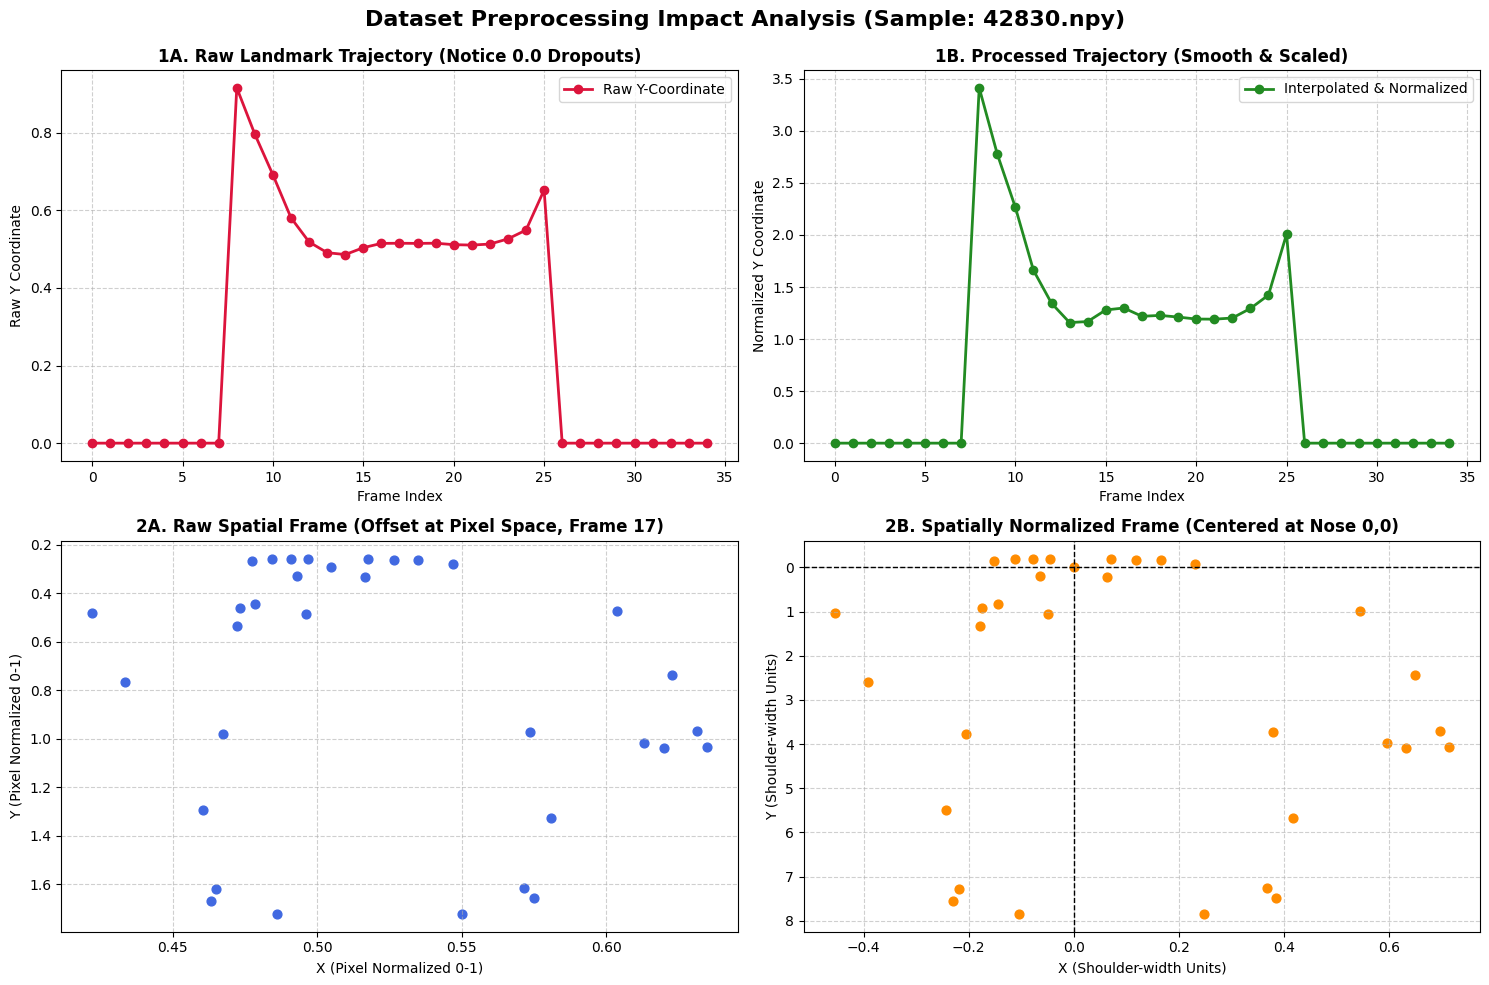


✅ Visualization saved to Drive at: /content/drive/MyDrive/SignLanguageProject/preprocessing_impact_visualization.png


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DIRECTORY SETUP ---
RAW_DIR = '/content/drive/MyDrive/SignLanguageProject/numpy_landmarks_top100'
NORM_DIR = '/content/drive/MyDrive/SignLanguageProject/normalized_landmarks'
SAVE_PATH = '/content/drive/MyDrive/SignLanguageProject/preprocessing_impact_visualization.png'

# --- 2. FIND A SAMPLE FILE COMMON TO BOTH DIRECTORIES ---
raw_files = {os.path.basename(f) for f in glob.glob(os.path.join(RAW_DIR, '*.npy'))}
norm_files = {os.path.basename(f) for f in glob.glob(os.path.join(NORM_DIR, '*.npy'))}

common_files = list(raw_files.intersection(norm_files))
if not common_files:
    raise FileNotFoundError("No common .npy files found between raw and normalized directories.")

sample_file = common_files[0]
print(f"Generating visualization for sample file: {sample_file}")

raw_data = np.load(os.path.join(RAW_DIR, sample_file))
norm_data = np.load(os.path.join(NORM_DIR, sample_file))

# --- 3. PLOT 1: TRAJECTORY & INTERPOLATION COMPARISON ---
# Extract Right Wrist Y-coordinate over frames (Index 196 in raw array: x=195, y=196, z=197)
raw_wrist_y = raw_data[:, 196]
norm_wrist_y = norm_data[:, 196]
frames = np.arange(len(raw_data))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Dataset Preprocessing Impact Analysis (Sample: {sample_file})', fontsize=16, fontweight='bold')

# Plot 1A: Raw Wrist Trajectory (Shows drops to 0)
axes[0, 0].plot(frames, raw_wrist_y, color='crimson', marker='o', linewidth=2, label='Raw Y-Coordinate')
axes[0, 0].set_title('1A. Raw Landmark Trajectory (Notice 0.0 Dropouts)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frame Index')
axes[0, 0].set_ylabel('Raw Y Coordinate')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend()

# Plot 1B: Processed Wrist Trajectory (Smooth & Normalized)
axes[0, 1].plot(frames, norm_wrist_y, color='forestgreen', marker='o', linewidth=2, label='Interpolated & Normalized')
axes[0, 1].set_title('1B. Processed Trajectory (Smooth & Scaled)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Frame Index')
axes[0, 1].set_ylabel('Normalized Y Coordinate')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].legend()

# --- 4. PLOT 2: SPATIAL CENTERING COMPARISON (Mid-video Frame) ---
mid_frame = len(raw_data) // 2

# Extract Pose X,Y (indices 0 to 131, step by 4)
raw_pose_x = raw_data[mid_frame, 0:132:4]
raw_pose_y = raw_data[mid_frame, 1:132:4]

norm_pose_x = norm_data[mid_frame, 0:132:4]
norm_pose_y = norm_data[mid_frame, 1:132:4]

# Plot 2A: Raw Skeleton Space
axes[1, 0].scatter(raw_pose_x, raw_pose_y, color='royalblue', s=40)
axes[1, 0].set_title(f'2A. Raw Spatial Frame (Offset at Pixel Space, Frame {mid_frame})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('X (Pixel Normalized 0-1)')
axes[1, 0].set_ylabel('Y (Pixel Normalized 0-1)')
axes[1, 0].invert_yaxis() # Invert Y to match image coordinate space
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 2B: Normalized Skeleton Space (Centered at 0,0)
axes[1, 1].scatter(norm_pose_x, norm_pose_y, color='darkorange', s=40)
axes[1, 1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1, 1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1, 1].set_title(f'2B. Spatially Normalized Frame (Centered at Nose 0,0)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('X (Shoulder-width Units)')
axes[1, 1].set_ylabel('Y (Shoulder-width Units)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save visualization
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print(f"\n✅ Visualization saved to Drive at: {SAVE_PATH}")

# Data Augmentation (Left/Right Invariance)

In [ ]:
import os
import glob
import numpy as np
from tqdm import tqdm

# --- 1. DIRECTORY CONFIGURATION ---
INPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/normalized_landmarks'
OUTPUT_DIR = '/content/drive/MyDrive/SignLanguageProject/augmented_landmarks'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def mirror_sequence(sequence):
    """
    Creates a left-handed mirrored version of a sequence:
    1. Inverts all X-coordinates (multiplies by -1.0).
    2. Swaps Left Hand (indices 132:195) and Right Hand (indices 195:258) arrays.
    """
    mirrored = sequence.copy()

    # 1. Invert X coordinates
    pose_x = np.arange(0, 132, 4)
    lh_x = np.arange(132, 195, 3)
    rh_x = np.arange(195, 258, 3)

    all_x = np.concatenate([pose_x, lh_x, rh_x])
    mirrored[:, all_x] = -1.0 * mirrored[:, all_x]

    # 2. Swap Left and Right Hand slices
    lh_original = mirrored[:, 132:195].copy()
    rh_original = mirrored[:, 195:258].copy()

    mirrored[:, 132:195] = rh_original
    mirrored[:, 195:258] = lh_original

    return mirrored

# --- 2. EXECUTE AUGMENTATION BATCH ---
npy_files = glob.glob(os.path.join(INPUT_DIR, '*.npy'))
print(f"Augmenting {len(npy_files)} normalized sequences...")

for file_path in tqdm(npy_files, desc="Mirroring Sequences"):
    filename = os.path.basename(file_path)
    base_name = os.path.splitext(filename)[0]

    orig_save_path = os.path.join(OUTPUT_DIR, f"{base_name}.npy")
    aug_save_path = os.path.join(OUTPUT_DIR, f"{base_name}_aug.npy")

    try:
        data = np.load(file_path)

        # Save original normalized sequence
        if not os.path.exists(orig_save_path):
            np.save(orig_save_path, data)

        # Generate and save mirrored sequence
        if not os.path.exists(aug_save_path):
            mirrored_data = mirror_sequence(data)
            np.save(aug_save_path, mirrored_data)

    except Exception as e:
        print(f"Failed to augment {filename}: {e}")

final_count = len(glob.glob(os.path.join(OUTPUT_DIR, '*.npy')))
print("\n" + "="*50)
print("✅ Data Augmentation Complete!")
print(f"Total sequences now ready for model training: {final_count}")
print(f"Final production dataset folder: {OUTPUT_DIR}")
print("="*50)

Augmenting 953 normalized sequences...


Mirroring Sequences: 100%|██████████| 953/953 [00:44<00:00, 21.65it/s]



✅ Data Augmentation Complete!
Total sequences now ready for model training: 1906
Final production dataset folder: /content/drive/MyDrive/SignLanguageProject/augmented_landmarks
